In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# The Data

data = pd.read_csv('/content/drive/MyDrive/Credit Card Fraud Colab Folder/credit_card_fraud.csv')
data

,V1,V2\r\n,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,V29,time,fraud
0,67116.0,-0.241374,-0.043836,1.545847,-0.950404,-0.819948,0.847419,-0.786322,-1.420254,1.645278,...,1.222000,-1.007936,-0.415337,-0.336823,1.033332,0.848539,0.117121,0.092623,96.35,otherwise
1,125495.0,-2.134432,-2.219310,0.969065,-2.858480,0.693123,-1.315593,0.284006,0.149392,1.182680,...,0.579502,0.743960,0.519019,-0.354719,0.373946,-0.319379,-0.056289,0.155978,276.73,otherwise
2,67705.0,-0.862259,-0.224703,2.308340,-1.941343,-0.321210,1.954794,-0.942382,0.729052,0.090916,...,0.121589,0.683341,-0.590164,-1.645139,0.665159,-0.005705,0.219394,0.098477,2.00,otherwise
3,64782.0,1.241610,-0.051895,0.579918,-0.115431,-0.579488,-0.548451,-0.269573,-0.041116,0.353210,...,-0.103847,-0.237586,0.124342,0.143650,0.053582,0.933286,-0.052477,0.006476,1.54,otherwise
4,31866.0,-0.655824,0.759808,2.144253,0.490666,0.103953,0.391045,0.159626,0.109992,0.174640,...,0.006465,0.210599,-0.292795,-0.423010,0.028267,-0.420763,0.045606,0.140026,9.99,otherwise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28474,164675.0,-0.179026,0.943564,0.159355,0.713100,1.087442,0.390270,0.802591,0.088052,-0.341001,...,0.212203,0.978882,-0.493097,-1.063402,0.173113,-0.200831,0.453460,0.223779,8.00,otherwise
28475,72999.0,-3.826287,-2.288348,0.843972,-0.288038,2.748319,-0.529788,0.505155,-0.843771,0.950461,...,-0.992128,-0.485620,0.487403,-1.108481,0.308781,-0.033623,-0.958645,0.286987,11.83,otherwise
28476,128081.0,2.071255,-0.433516,-3.071114,-1.575368,0.736294,-1.725837,1.051549,-0.685897,0.997689,...,0.317018,0.971460,-0.317930,0.587448,0.871183,0.199648,-0.103865,-0.073293,90.25,otherwise
28477,132815.0,2.123341,-0.257764,-1.466731,-0.714225,0.026685,-1.049025,0.096077,-0.281468,0.837886,...,-0.306540,-0.838143,0.384608,0.675921,-0.370399,0.512908,-0.109321,-0.061377,4.00,otherwise


In [3]:
# Data Feature Space

data.columns=['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'time',
       'fraud']

In [4]:
# Output Feature

data['fraud']

,fraud
0,otherwise
1,otherwise
2,otherwise
3,otherwise
4,otherwise
...,...
28474,otherwise
28475,otherwise
28476,otherwise
28477,otherwise


In [5]:
# The output column is a String, let us convert it to numeric 1/0

data['fraud'] = data['fraud'].apply(lambda x: 1 if x == 'fraud' else 0)

# Other alternate way

#data['fraud'] = data['fraud'].map({'fraud': 1, 'otherwise': 0})

In [6]:
# Output Feature column now

data['fraud']

,fraud
0,0
1,0
2,0
3,0
4,0
...,...
28474,0
28475,0
28476,0
28477,0


In [7]:
# Important features in dataset

data.corr()['fraud'].abs().sort_values(ascending=False).drop('fraud',axis=0)

,fraud
V18,0.341440
V15,0.291628
V13,0.269456
V11,0.241716
V8,0.230698
V4,0.213233
V17,0.211741
V12,0.152727
V5,0.137386
V19,0.126693


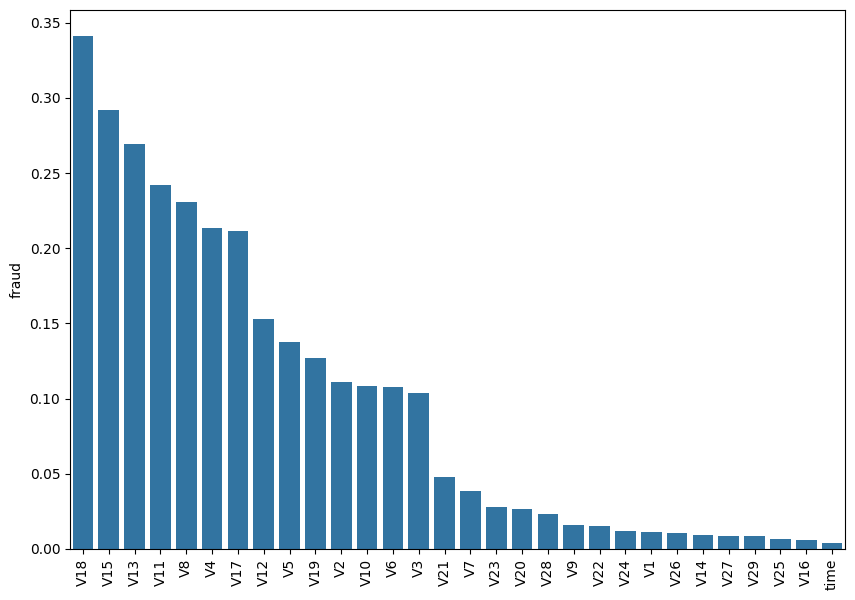

In [8]:
# Important features in dataset - visualised

plt.figure(figsize=(10,7),dpi=100);
sns.barplot(data.corr()['fraud'].abs().sort_values(ascending=False).drop('fraud',axis=0));
plt.xticks(rotation=90);

In [9]:
# dataset shape -> num of rows, num of columns

data.shape

(28479, 31)

In [10]:
# data information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28479 entries, 0 to 28478
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      28479 non-null  float64
 1   V2      28479 non-null  float64
 2   V3      28479 non-null  float64
 3   V4      28479 non-null  float64
 4   V5      28479 non-null  float64
 5   V6      28479 non-null  float64
 6   V7      28479 non-null  float64
 7   V8      28479 non-null  float64
 8   V9      28479 non-null  float64
 9   V10     28479 non-null  float64
 10  V11     28479 non-null  float64
 11  V12     28479 non-null  float64
 12  V13     28479 non-null  float64
 13  V14     28479 non-null  float64
 14  V15     28479 non-null  float64
 15  V16     28479 non-null  float64
 16  V17     28479 non-null  float64
 17  V18     28479 non-null  float64
 18  V19     28479 non-null  float64
 19  V20     28479 non-null  float64
 20  V21     28479 non-null  float64
 21  V22     28479 non-null  float64
 22

In [11]:
# data statistics

data.describe().transpose().drop('fraud')

,count,mean,std,min,25%,50%,75%,max
V1,28479.0,94910.912883,47460.858008,0.000000,54490.500000,84809.000000,139212.000000,172768.000000
V2,28479.0,0.005264,1.929270,-33.404082,-0.914167,0.023006,1.315290,2.420346
V3,28479.0,0.008189,1.605464,-38.436817,-0.606480,0.070652,0.809615,22.057729
V4,28479.0,-0.006628,1.510966,-30.558697,-0.898571,0.171935,1.015364,3.893024
V5,28479.0,0.010107,1.412474,-5.175917,-0.833674,-0.008913,0.748527,12.699542
V6,28479.0,0.011407,1.362165,-27.737487,-0.688305,-0.050503,0.625599,29.162172
V7,28479.0,-0.005186,1.316657,-20.367836,-0.765053,-0.271271,0.405032,16.410638
V8,28479.0,-0.009172,1.209929,-43.557242,-0.553304,0.042792,0.580064,21.444508
V9,28479.0,0.004328,1.166409,-41.044261,-0.206726,0.022557,0.328605,19.587773
V10,28479.0,0.008098,1.106222,-13.320155,-0.635420,-0.047531,0.599891,10.370658


<Axes: >

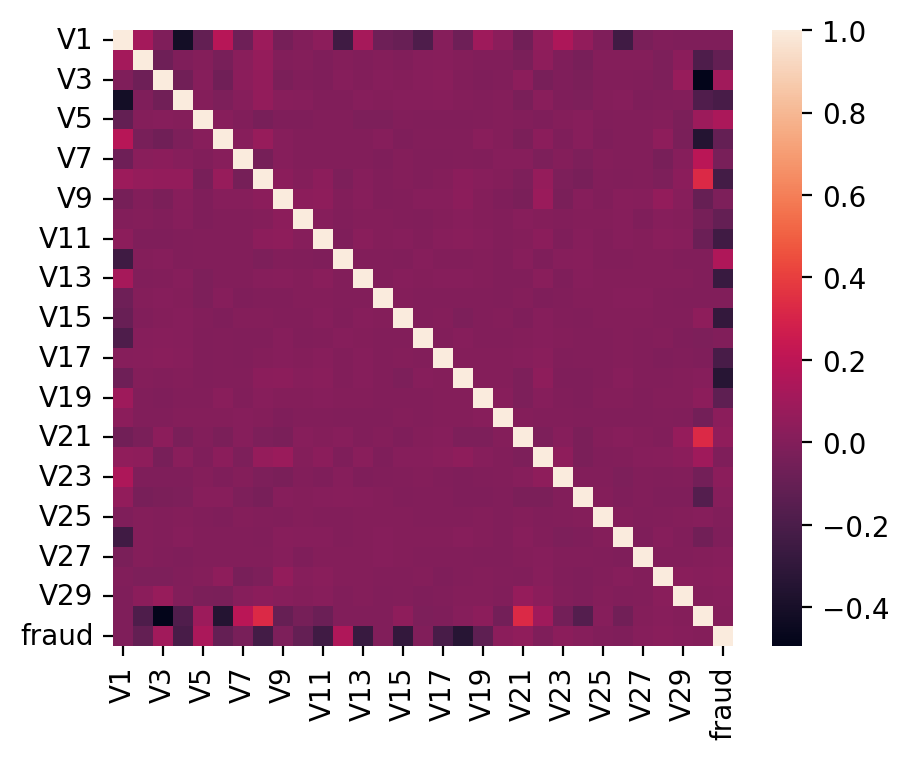

In [12]:
plt.figure(figsize=(5,4),dpi=200)
sns.heatmap(data.corr())

In [ ]:
# correlation visualised for various important features of the column

data_imp = (data.corr()['fraud'].abs())[data.corr()['fraud'].abs()>0.2].sort_values(ascending=False)
data_imp = data[data_imp.index]

sns.pairplot(data_imp, hue='fraud')

In [ ]:
# Visualising class imbalanace - the major drawback in this data

# imbalance percentage

fraud = data[data["fraud"] == 1]
normal = data[data["fraud"] == 0]

print(f"Fraud Percentage: {round(len(fraud)/len(data)*100, 5)}%")

# visiualing the imbalance

data["fraud"].value_counts().plot.pie(autopct='%1.2f%%');
plt.title("Class Distribution");

In [ ]:
# missing data (done for explanatory purposes and to ensure if the data is authentic are not)

data.isnull().sum()

# no null values found

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Amount distribution for all data
axes[0].set_xlabel("Amount (V1)")
axes[0].set_ylabel("Count")
axes[0].set_title("Transaction Amount Distribution (All Data)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
sns.histplot(data=data, x='V1', ax=axes[0],bins=20,palette='viridis');

# Amount distribution for fraud transactions
axes[1].set_xlabel("Amount (V1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Transaction Amount Distribution (Fraud Only)")
axes[1].tick_params(axis='x', rotation=90)
sns.histplot(data=data[data["fraud"] == 1], x='V1', hue='fraud', ax=axes[1],palette='viridis');

# Amount distribution for legit transactions
axes[2].set_xlabel("Amount (V1)")
axes[2].set_ylabel("Count")
axes[2].set_title("Transaction Amount Distribution (Legit Only)")
axes[2].tick_params(axis='x', rotation=90)
sns.histplot(data=data[data["fraud"] == 0], x='V1', hue='fraud', ax=axes[2],palette='viridis');

plt.tight_layout();
plt.show();

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Amount distribution for all data
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Count")
axes[0].set_xlim()
axes[0].set_title("Transaction Time Distribution (All Data)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
sns.histplot(data=data, x='time', ax=axes[0],bins=20,palette='viridis');

# Amount distribution for fraud transactions
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Count")
axes[1].set_title("Transaction Time Distribution (Fraud Only)")
axes[1].tick_params(axis='x', rotation=90)
sns.histplot(data=data[data["fraud"] == 1], x='V1', ax=axes[1],palette='pink');

# Amount distribution for legit transactions
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Count")
axes[2].set_title("Transaction Time Distribution (Legit Only)")
axes[2].tick_params(axis='x', rotation=90)
sns.histplot(data=data[data["fraud"] == 0], x='time', ax=axes[2]);

plt.tight_layout();
plt.show();